In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/eda_total_data.csv')
# 컬럼명 확인
print(df.head())

     dcl_id        date day_of_week  before_rest  rain_status  end_g  sum_g  \
0  dcl_0511  2026-05-11           월            0            0   3583  20650   
1  dcl_0512  2026-05-12           화            0            0    350  28300   
2  dcl_0515  2026-05-15           금            1            0   8100  23450   
3  dcl_0518  2026-05-18           월            0            0    343  29500   
4  dcl_0519  2026-05-19           화            0            0   6777  16150   

   cnt    act_g  cumul_16_19  cumul_20_22  
0   30  20650.0        11550         9100  
1   36  28300.0        16600        11700  
2   31  23450.0        12300        11150  
3   38  29500.0        12600        16900  
4   25  16150.0         9200         6950  


### 한글 폰트 설정


In [ ]:
import subprocess
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 적용:', plt.rcParams['font.family'])


폰트 적용: ['NanumGothic']


### 재사용 함수 — 정규성 / 등분산성 검정

아래에서 정규성 검정(Shapiro-Wilk)과 등분산성 검정(Levene)을 여러 그룹·여러 가설에서 반복해서 쓰므로, 함수로 뽑아둔다.


In [ ]:
def check_normality(data, label):
    """Shapiro-Wilk 정규성 검정을 수행하고 결과를 출력한다."""
    stat, p = stats.shapiro(data)
    print(f"[{label}] 샤피로 윌크: 통계량={stat:.4f}, p-value={p:.4f}")
    print("  → 정규성 만족" if p > 0.05 else "  → 정규성 비만족")
    return stat, p


def check_variance_homogeneity(*groups, labels=None):
    """Levene 등분산성 검정을 수행하고 결과를 출력한다."""
    stat, p = stats.levene(*groups)
    tag = f" ({', '.join(labels)})" if labels else ""
    print(f"Levene 검정{tag}: 통계량={stat:.4f}, p-value={p:.4f}")
    print("  → 등분산 동일" if p > 0.05 else "  → 등분산 비동일")
    return stat, p


---
## EDA — 분포 및 이상치 확인


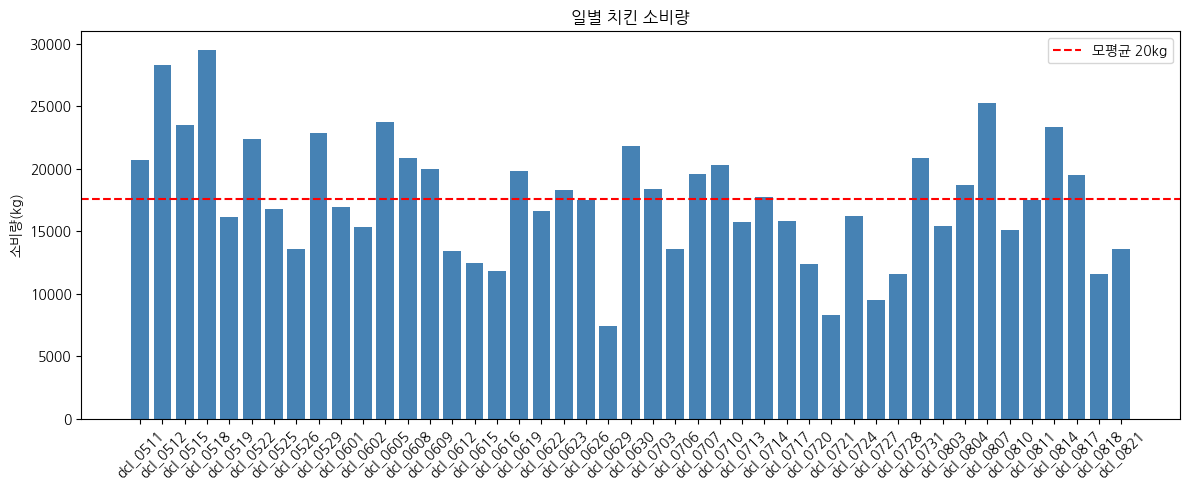

In [ ]:
plt.figure (figsize=(12,5))


plt.bar(df['dcl_id'],df['sum_g'], color='steelblue')
plt.axhline(y=df['sum_g'].mean(), color='red', linestyle='--', label='모평균 20kg')
plt.xticks(rotation=45)
plt.ylabel('소비량(kg)')
plt.title('일별 치킨 소비량')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,before_rest,rain_status,end_g,sum_g,cnt,act_g,cumul_16_19,cumul_20_22
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,0.400000,0.133333,3326.866667,17545.555556,23.688889,16868.888888,9827.777778,7694.444444
std,0.495434,0.343776,3146.813458,4898.641071,6.240710,5583.216416,3069.286184,3231.032452
min,0.000000,0.000000,219.000000,7400.000000,12.000000,4200.000000,3450.000000,1900.000000
25%,0.000000,0.000000,792.000000,13600.000000,19.000000,13550.000000,7450.000000,5000.000000
50%,0.000000,0.000000,2264.000000,17500.000000,24.000000,16750.000000,9250.000000,7000.000000
75%,1.000000,0.000000,4495.000000,20650.000000,28.000000,20650.000000,12300.000000,10150.000000
max,1.000000,1.000000,12445.000000,29500.000000,38.000000,29500.000000,16600.000000,16900.000000


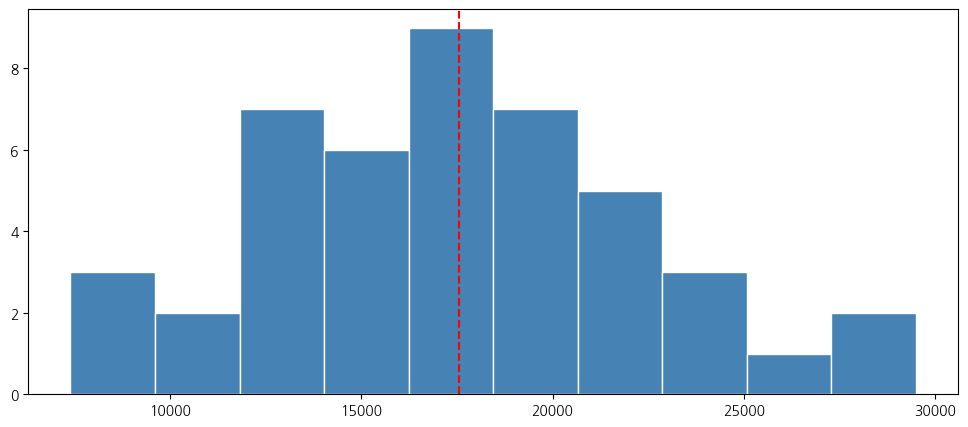

In [ ]:
plt.figure(figsize=(12, 5))
plt.hist(df['sum_g'], color='steelblue',bins=10,edgecolor='white')
plt.axvline(x=df['sum_g'].mean(), color='red', linestyle='--', label='평균')
plt.show()

### 주문 소비량 이상치 스캔 (IQR 기준)


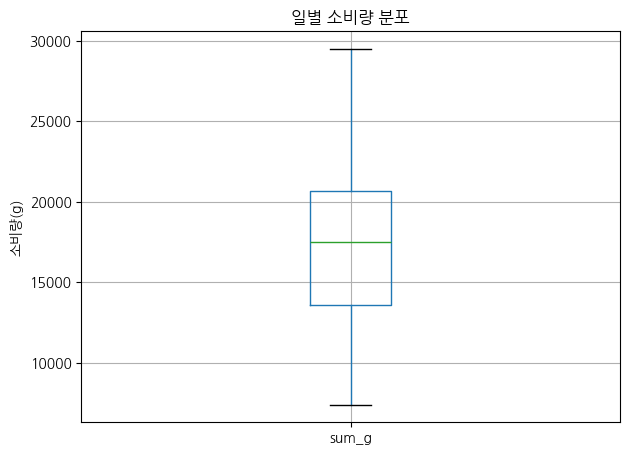

In [ ]:
df.boxplot(column='sum_g',  showfliers=True)
plt.title('일별 소비량 분포')
plt.suptitle('')
plt.ylabel('소비량(g)')
plt.tight_layout()
plt.show()


In [ ]:
q1 = df['sum_g'].quantile(0.25)
q3 = df['sum_g'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = df[(df['sum_g'] < lower) | (df['sum_g'] > upper)]
print(f"IQR 범위: [{lower:.0f}, {upper:.0f}]")
print(f"이상치 개수: {len(outliers)}")
print(outliers)


IQR 범위: [3025, 31225]
이상치 개수: 0
Empty DataFrame
Columns: [dcl_id, date, day_of_week, before_rest, rain_status, end_g, sum_g, cnt, act_g, cumul_16_19, cumul_20_22]
Index: []


---
## 모평균 20kg과 일표본 T검정 (기존 경험론적 추정량 차이검증)


In [ ]:
check_normality(df['sum_g'], '전체 표본')

[전체 표본] 샤피로 윌크: 통계량=0.9902, p-value=0.9646
  → 정규성 만족


(np.float64(0.9901526461873297), np.float64(0.964568744929327))

In [ ]:
stat, p = stats.ttest_1samp(df['sum_g'], popmean=20000)
print(f't검정: 통계량={stat:.4f}, p-value={p:.4f}')

if p < 0.05:
    print('귀무가설 기각 → 일평균 소비량은 20kg이 아니다')
else:
    print('귀무가설 채택 → 일평균 소비량은 20kg과 유의미한 차이 없다')

t검정: 통계량=-3.3611, p-value=0.0016
귀무가설 기각 → 일평균 소비량은 20kg이 아니다


---
### 요일별 주문 소비량 차이 가설 (H1, ANOVA)
## 범주별 데이터 15개 적재


### 요일별 요약 통계


In [ ]:
summary = df.groupby('day_of_week')['sum_g'].describe()
print(summary)

             count          mean          std      min      25%      50%  \
day_of_week                                                                
금             15.0  19793.333333  3811.208407  13450.0  16875.0  20250.0   
월             15.0  16160.000000  5278.230223   7400.0  13000.0  15750.0   
화             15.0  16683.333333  4976.576084   8300.0  12700.0  17500.0   

                 75%      max  
day_of_week                    
금            23100.0  25250.0  
월            18225.0  29500.0  
화            19150.0  28300.0  


### 요일별 분포 — Boxplot


<Figure size 800x500 with 0 Axes>

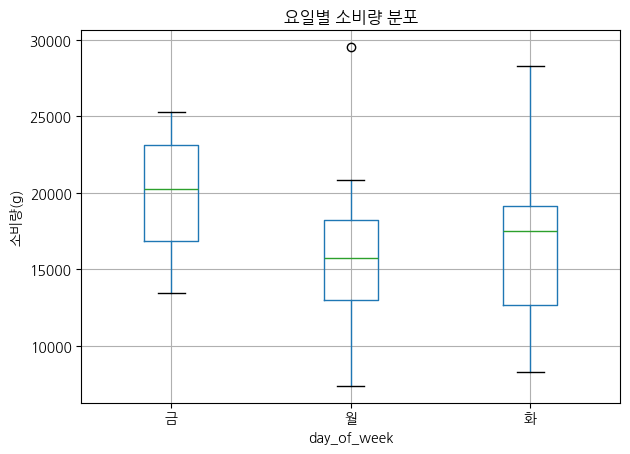

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column='sum_g', by='day_of_week')
plt.title('요일별 소비량 분포')
plt.suptitle('')
plt.ylabel('소비량(g)')
plt.tight_layout()
plt.show()


### 표본 정규성 시각화 확인


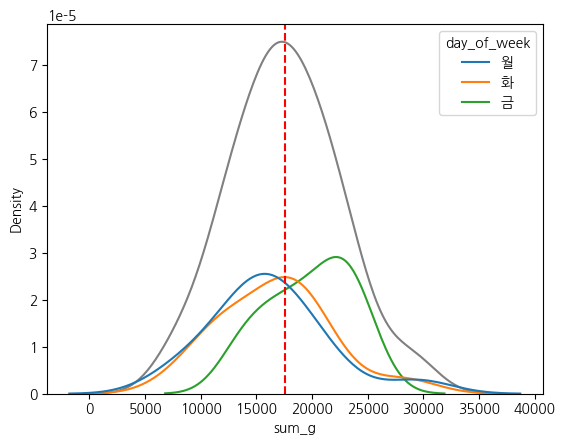

In [ ]:
sns.kdeplot(data=df, x='sum_g',color='gray')
sns.kdeplot(data=df, x='sum_g', hue='day_of_week')
plt.axvline(x=df['sum_g'].mean(), color='red', linestyle='--', label='평균')
plt.show()

In [ ]:
mon_data=df[df['day_of_week']=='월']
tue_data=df[df['day_of_week']=='화']
fri_data=df[df['day_of_week']=='금']

In [ ]:
for label, group in [('월', mon_data), ('화', tue_data), ('금', fri_data)]:
    check_normality(group['sum_g'], label)


[월] 샤피로 윌크: 통계량=0.9423, p-value=0.4124
  → 정규성 만족
[화] 샤피로 윌크: 통계량=0.9620, p-value=0.7279
  → 정규성 만족
[금] 샤피로 윌크: 통계량=0.9367, p-value=0.3427
  → 정규성 만족


## 등분산성 확인


In [ ]:
check_variance_homogeneity(mon_data['sum_g'], tue_data['sum_g'], fri_data['sum_g'],
                            labels=['월', '화', '금'])


Levene 검정 (월, 화, 금): 통계량=0.1661, p-value=0.8475
  → 등분산 동일


(np.float64(0.16612234475065343), np.float64(0.8474963667233579))

## 등분산 및 정규성 입증 후 ANOVA 분산 분석 시행


In [ ]:
anova=stats.f_oneway(mon_data['sum_g'],tue_data['sum_g'],fri_data['sum_g'])
print(f'F-statistic: {anova.statistic:.4f}, p-value: {anova.pvalue:.4f}')

F-statistic: 2.5853, p-value: 0.0873


### 귀무가설 기각 X
### 요일별 평균 차이는 유의하지 아니함


---
# H2. 평일 주중과 연휴 및 연휴전날 평균 소비량 차이
### 고정 요일이 월,화,금 임으로 평일 과 주말 연휴 전날의 평균 소비량 차이 확인
### 데이터 갯수는 월화 (평일) 금(연휴전일) 로 불균형 존재 (27일vs18일)


In [ ]:
H2_data=df.copy()
H2_data.head()

,dcl_id,date,day_of_week,before_rest,rain_status,end_g,sum_g,cnt,act_g,cumul_16_19,cumul_20_22
0,dcl_0511,2026-05-11,월,0,0,3583,20650,30,20650.0,11550,9100
1,dcl_0512,2026-05-12,화,0,0,350,28300,36,28300.0,16600,11700
2,dcl_0515,2026-05-15,금,1,0,8100,23450,31,23450.0,12300,11150
3,dcl_0518,2026-05-18,월,0,0,343,29500,38,29500.0,12600,16900
4,dcl_0519,2026-05-19,화,0,0,6777,16150,25,16150.0,9200,6950


In [ ]:
## 0  : 평일(월,화) ,1 : 연휴 전일 및 연휴( 공휴일 및 금)
group_mean = df.groupby('before_rest')['sum_g'].mean()
group_mean

,sum_g
before_rest,
0,16335.185185
1,19361.111111


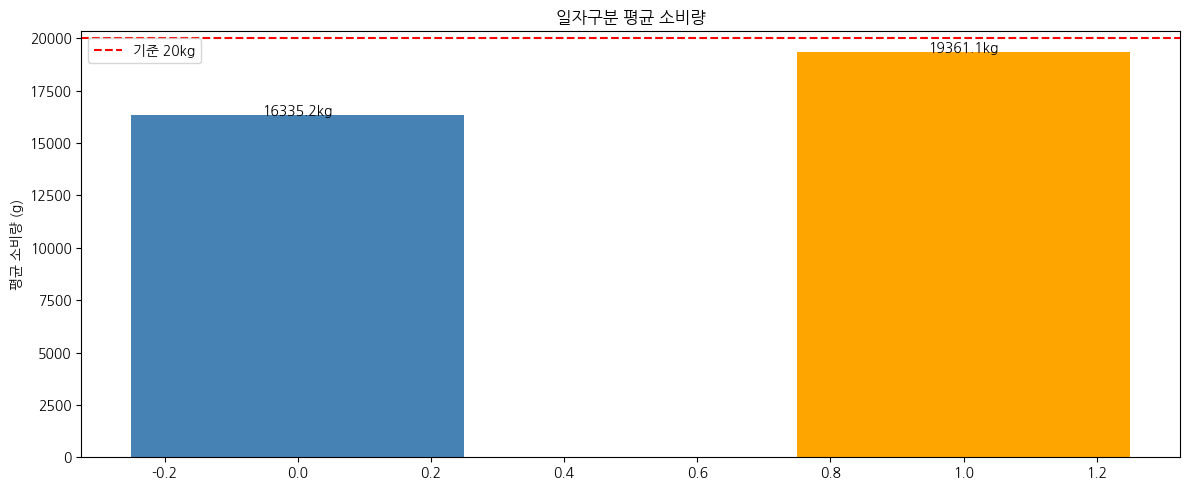

In [ ]:
plt.figure(figsize=(12,5))


bars = plt.bar(group_mean.index, group_mean.values,
               color=['steelblue', 'orange'], width=0.5)

# 막대 위에 값 표시
for bar, val in zip(bars, group_mean.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}kg', ha='center')

plt.axhline(y=20000, color='red', linestyle='--', label='기준 20kg')
plt.ylabel('평균 소비량 (g)')
plt.title('일자구분 평균 소비량')
plt.legend()
plt.tight_layout()
plt.show()

## 정규성 검증


In [ ]:
for x in H2_data['before_rest'].unique():
    label = '평일' if x == 0 else '휴일전일'
    check_normality(H2_data[H2_data['before_rest'] == x]['sum_g'], label)


[평일] 샤피로 윌크: 통계량=0.9563, p-value=0.3037
  → 정규성 만족
[휴일전일] 샤피로 윌크: 통계량=0.9521, p-value=0.4590
  → 정규성 만족


In [ ]:
group_0=H2_data[H2_data['before_rest']==0]
group_1= H2_data[H2_data['before_rest'] == 1]

## 등분산 검정


In [ ]:
check_variance_homogeneity(group_0['sum_g'], group_1['sum_g'], labels=['평일', '휴일전일'])


Levene 검정 (평일, 휴일전일): 통계량=1.1067, p-value=0.2987
  → 등분산 동일


(np.float64(1.106709734664809), np.float64(0.29867445731543074))

## 독립표본 검정


In [ ]:
t,p = stats.ttest_ind(group_0['sum_g'],group_1['sum_g'],equal_var=True, alternative='two-sided')
print(f't검정: 통계량={t:.4f}, p-value={p:.4f}')
if p > 0.05:
  print("귀무가설 채택")
else :
  print("귀무가설 기각")

t검정: 통계량=-2.1079, p-value=0.0409
귀무가설 기각


In [ ]:
t,p = stats.ttest_ind(group_0['sum_g'],group_1['sum_g'],equal_var=True, alternative='less')
print(f't검정: 통계량={t:.4f}, p-value={p:.4f}')
if p > 0.05:
  print("귀무가설 채택")
else :
  print("귀무가설 기각")

t검정: 통계량=-2.1079, p-value=0.0205
귀무가설 기각


In [ ]:
summary_df = pd.DataFrame({
    'GROUP':['group_0','group_1'],
    'N': [len(group_0),len(group_1)],
    '평균 소비량': [group_0['sum_g'].mean(), group_1['sum_g'].mean()],
    '표준편차': [group_0['sum_g'].std(), group_1['sum_g'].std()],
    '표준오차': [group_0['sum_g'].sem(), group_1['sum_g'].sem()]
})


In [ ]:
print(summary_df)

     GROUP   N        평균 소비량         표준편차         표준오차
0  group_0  27  16335.185185  5291.081299  1018.269071
1  group_1  18  19361.111111  3670.893286   865.237845


## 평일 주중과 특수일 주문량의 실제 효과 크기
### 클래스 불균형이 사전 관측 (보정 SD - Hedges'g)

In [ ]:
!pip install pingouin
import pingouin as pg

In [ ]:
g=pg.compute_effsize(group_0['sum_g'], group_1['sum_g'], eftype='hedges')
print(group_0['sum_g'].mean()-group_1['sum_g'].mean())
print(g)

-3025.925925925925
-0.630169303468121


### 평일과 특수일의 주문 소비량은 3kg 차이는 유의미한 통계 관측치로 확인됨과 동시에 0.63의 효과 차이를 보임.

---
## H3. 오후 주문 소비와 저녁 주문 소비의 차이가 발생한가
### 날짜 변화 통제를 위해 대응표본 t검정 시행


In [ ]:
H3_DATA=df.copy()
H3_DATA.head()

,dcl_id,date,day_of_week,before_rest,rain_status,end_g,sum_g,cnt,act_g,cumul_16_19,cumul_20_22
0,dcl_0511,2026-05-11,월,0,0,3583,20650,30,20650.0,11550,9100
1,dcl_0512,2026-05-12,화,0,0,350,28300,36,28300.0,16600,11700
2,dcl_0515,2026-05-15,금,1,0,8100,23450,31,23450.0,12300,11150
3,dcl_0518,2026-05-18,월,0,0,343,29500,38,29500.0,12600,16900
4,dcl_0519,2026-05-19,화,0,0,6777,16150,25,16150.0,9200,6950


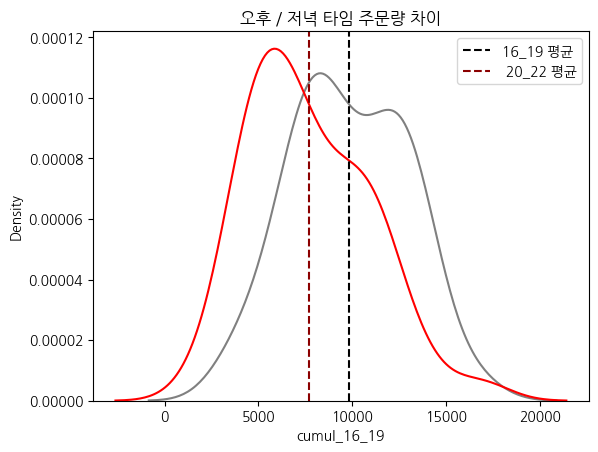

In [ ]:
sns.kdeplot(data=H3_DATA, x='cumul_16_19',color='gray')
sns.kdeplot(data=H3_DATA, x='cumul_20_22',color='red')
plt.axvline(x=H3_DATA['cumul_16_19'].mean(), color='black', linestyle='--', label='16_19 평균')
plt.axvline(x=H3_DATA['cumul_20_22'].mean(), color='darkred', linestyle='--', label=' 20_22 평균')
plt.title('오후 / 저녁 타임 주문량 차이')
plt.legend()
plt.show()

In [ ]:
h3_data=H3_DATA[['dcl_id','cumul_16_19','cumul_20_22']]
h3_data.head()

,dcl_id,cumul_16_19,cumul_20_22
0,dcl_0511,11550,9100
1,dcl_0512,16600,11700
2,dcl_0515,12300,11150
3,dcl_0518,12600,16900
4,dcl_0519,9200,6950


In [ ]:

diff = h3_data['cumul_16_19'] - h3_data['cumul_20_22']

# 1. 정규성 검정 (차이값 기준)
shapiro_stat, shapiro_p = stats.shapiro(diff)
print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

# 2. 이상치 확인
print(diff.describe())

# 3. 정규성 만족 시 -> paired t-test
t_stat, t_p = stats.ttest_rel(h3_data['cumul_16_19'], h3_data['cumul_20_22'])
print(f"Paired t-test: t={t_stat:.4f}, p={t_p:.4f}")

# 4. 정규성 위반 시 -> Wilcoxon signed-rank test (비모수 대안)
w_stat, w_p = stats.wilcoxon(h3_data['cumul_16_19'], h3_data['cumul_20_22'])
print(f"Wilcoxon: stat={w_stat:.4f}, p={w_p:.4f}")

Shapiro-Wilk: stat=0.9690, p=0.2661
count      45.000000
mean     2133.333333
std      3969.142339
min     -4850.000000
25%     -1300.000000
50%      2150.000000
75%      4750.000000
max      9950.000000
dtype: float64
Paired t-test: t=3.6055, p=0.0008
Wilcoxon: stat=246.0000, p=0.0022


### 두 시간대 주문 소비 차이 는 대략 2.2kg으로 유의미한 차이로 보여짐
### diff=(오후)-(저녁)임으로 t값의 양수부호로 오후 판매량 > 저녁 판매량을 의미


In [ ]:
cohens_d = diff.mean() / diff.std()
print(f"Cohen's d: {cohens_d:.4f}")

Cohen's d: 0.5375


In [ ]:
d_z = pg.compute_effsize(h3_data['cumul_16_19'], h3_data['cumul_20_22'],
                          paired=True, eftype='cohen_dz')
print(d_z)  # 0.5375가 나와야 함

0.5374796747011232


### 실제 효과 크기 차이도 0.53으로 중간 정도의 차이를 보임
